In [7]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
!unzip /content/drive/MyDrive/GreenAI/Trashnet/dataset-resized2.zip -d /content/dataset

Archive:  /content/drive/MyDrive/GreenAI/Trashnet/dataset-resized2.zip
   creating: /content/dataset/dataset-resized/
   creating: /content/dataset/dataset-resized/cardboard/
  inflating: /content/dataset/dataset-resized/cardboard/cardboard1.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard10.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard100.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard101.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard102.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard103.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard104.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard105.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard106.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard107.jpg  
  inflating: /content/dataset/dataset-resized/cardboard/cardboard108.jpg  
  i

In [9]:
!ls /content/dataset

dataset-resized


In [10]:
DATA_DIR = '/content/dataset/dataset-resized'

In [11]:
MY_CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=MY_CLASSES, # This forces the model to only use these 5 folders
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=MY_CLASSES,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(6, activation='softmax') # Exactly 6 output units
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting training on 5 classes...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Starting training on 5 classes...
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5356 - loss: 1.2170 - val_accuracy: 0.7327 - val_loss: 0.7349
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7577 - loss: 0.6786 - val_accuracy: 0.7525 - val_loss: 0.6342
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8096 - loss: 0.5457 - val_accuracy: 0.7624 - val_loss: 0.6125
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 951ms/step - accuracy: 0.8229 - loss: 0.4992 - val_accuracy: 0.7980 - val_loss: 0.5545
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8373 - loss: 0.4449 - val_accuracy: 0.8020 - val_loss: 0.5367
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8645 - loss: 0.4079 - val_accuracy: 0.8099 - val_loss: 0.5298
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 969ms/step - accuracy: 0.8694 - loss: 0.3728 - val_accuracy: 0.8040 - val_loss: 0.5215
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8823 - loss: 0

In [15]:
import tensorflow as tf

# Load your model (replace 'path_to_model' with your actual file path)
model = tf.keras.models.load_model('/content/drive/MyDrive/GreenAI/Trashnet/model.keras')

# Display the summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,358 (8.67 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 7,688 (30.04 KB)

In [16]:
# Evaluate on the validation dataset
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 6s/step - accuracy: 0.8218 - loss: 0.4909
Validation Accuracy: 82.18%


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Get all images and true labels from the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Print the report
# Ensure the target_names match the folders in your dataset
target_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Print the Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
              precision    recall  f1-score   support

   cardboard       0.91      0.83      0.87        83
       glass       0.78      0.94      0.85       103
       metal       0.91      0.77      0.83        78
       paper       0.83      0.87      0.85       124
     plastic       0.77      0.69      0.73        88
       trash       0.69      0.69      0.69        29

    accuracy                           0.82 

/tmp/ipykernel_2794/1591081019.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_names, y=f1_scores, palette='viridis')


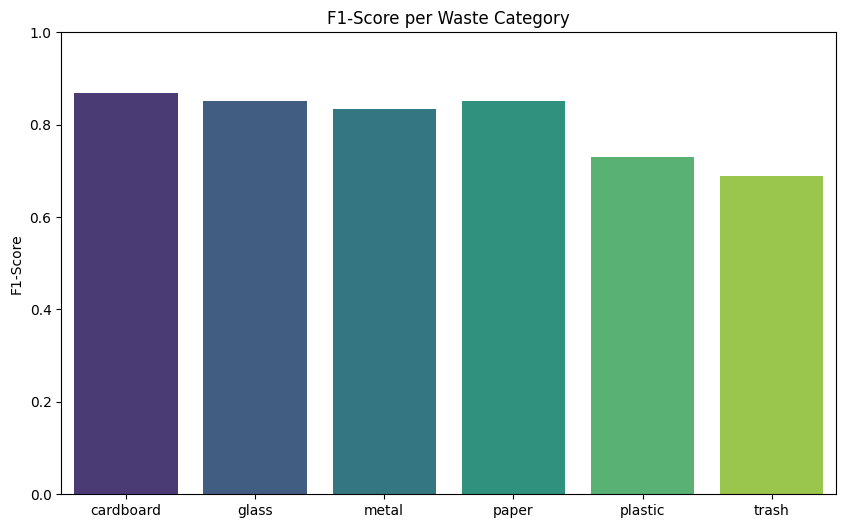

In [19]:
import seaborn as sns
from sklearn.metrics import f1_score

# Calculate F1 for each class
f1_scores = f1_score(y_true, y_pred, average=None)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_names, y=f1_scores, palette='viridis')
plt.title('F1-Score per Waste Category')
plt.ylabel('F1-Score')
plt.ylim(0, 1) # F1 score is between 0 and 1
plt.show()

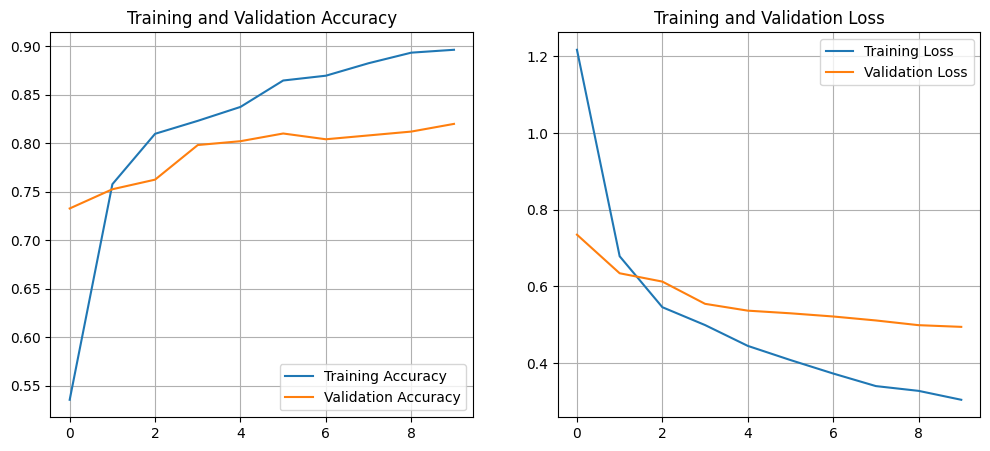

In [20]:
import matplotlib.pyplot as plt

# Assuming you save the fit result to a variable 'history'
# history = model.fit(train_ds, validation_data=val_ds, epochs=10)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(10)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


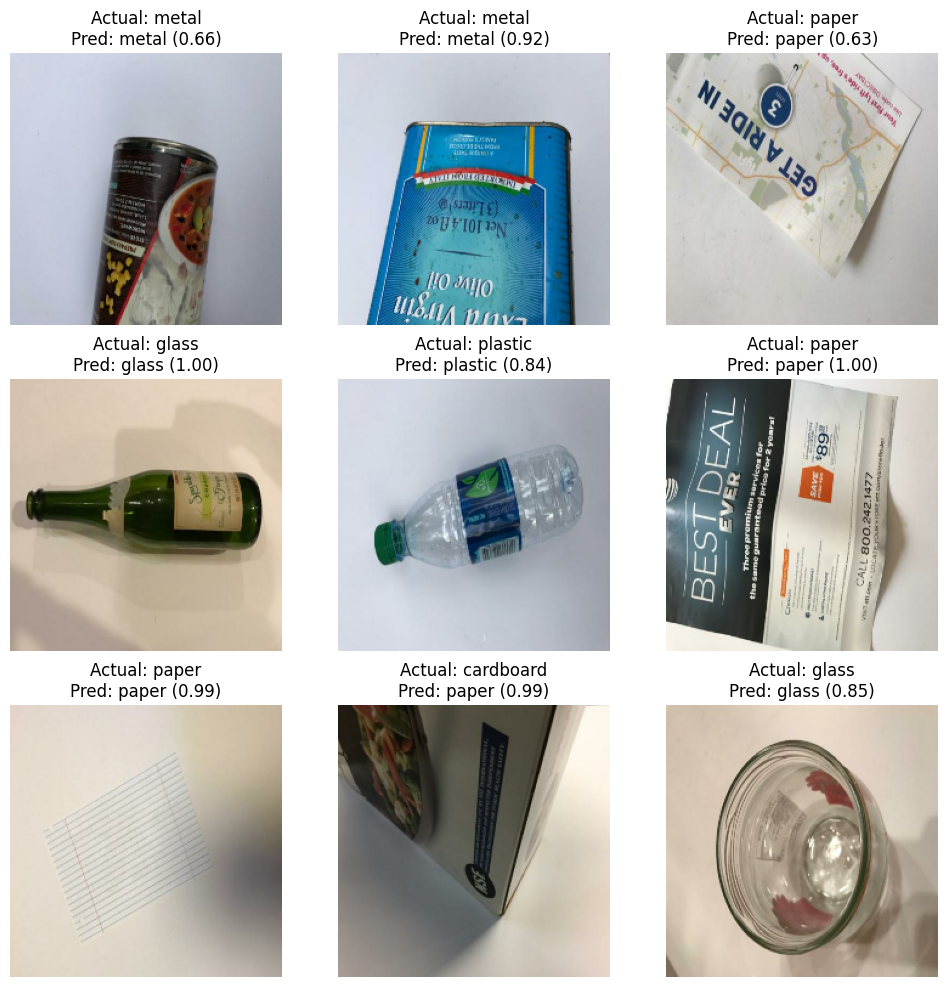

In [21]:
import matplotlib.pyplot as plt

# Take one batch from validation set
images, labels = next(iter(val_ds))
predictions = model.predict(images)

plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    actual = target_names[np.argmax(labels[i])]
    predicted = target_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i])

    plt.title(f"Actual: {actual}\nPred: {predicted} ({confidence:.2f})")
    plt.axis("off")

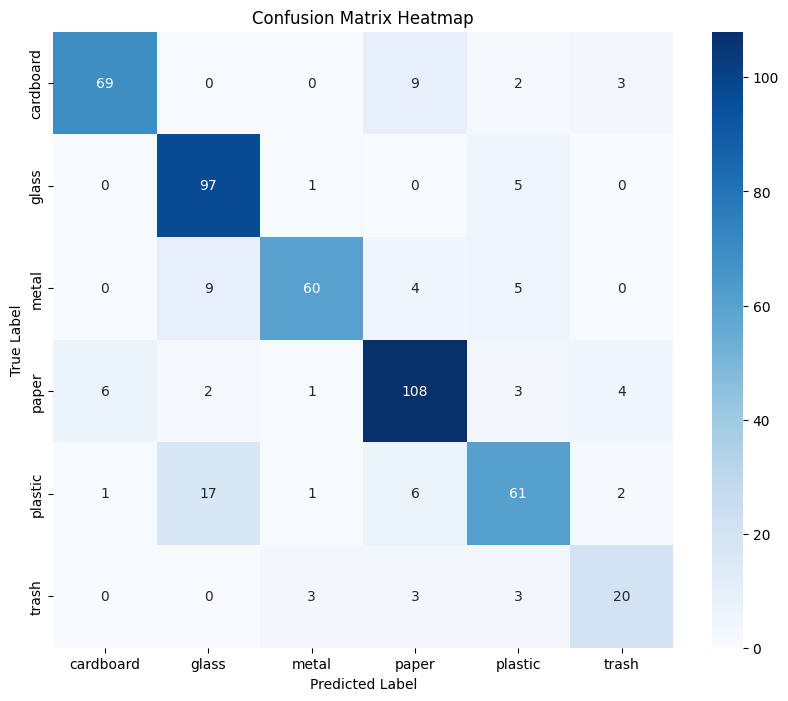

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix,
            annot=True,
            cmap="Blues",
            fmt='d',
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [23]:
def check_recyclable(label):
    recyclable_items = ["plastic", "paper", "metal", "glass", "cardboard"]

    if label.lower() in recyclable_items:
        return "Recyclable"
    else:
        return "Non-Recyclable"

In [24]:
model.save("/content/drive/MyDrive/GreenAI/Trashnet/model.keras")

In [27]:
import os
os.listdir()

['.config', 'dataset', 'drive', 'sample_data']